# Clusterização de meses da economia brasileira
## Experimento A: K-means | Experimento B: hierárquico Ward

Cada linha representa um mês. `IPCA` e `Regime_Inflacao` ficam fora dos modelos e são consultados depois, apenas para interpretar os grupos.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram
plt.rcParams.update({'figure.dpi': 115, 'axes.grid': True, 'grid.alpha': 0.2})

In [2]:
caminhos = [Path('../5_Tabelas_e_Dados/df_macro_agosto2026.csv'), Path('Entrega_Classroom/5_Tabelas_e_Dados/df_macro_agosto2026.csv')]
caminho = next((p for p in caminhos if p.is_file()), None)
if caminho is None:
    raise FileNotFoundError('Base de dados não encontrada.')
df = pd.read_csv(caminho, parse_dates=['Date']).sort_values('Date')
assert df['Date'].is_unique and df['Date'].notna().all()
referencia = df.set_index('Date')[['IPCA', 'Regime_Inflacao']]
print(f'Base: {len(df)} meses, de {df.Date.min():%m/%Y} a {df.Date.max():%m/%Y}')
print('Regime_Inflacao é uma referência derivada do IPCA mensal, não um rótulo de treino.')

Base: 174 meses, de 03/2012 a 08/2026
Regime_Inflacao é uma referência derivada do IPCA mensal, não um rótulo de treino.


## A. Indicadores macroeconômicos com K-means

Retiramos os componentes do IPCA, o índice geral e o regime. Para reduzir redundância entre indicadores, exigimos correlação alta tanto nos níveis quanto nas variações mensais. Depois padronizamos as variáveis.

In [3]:
componentes_ipca = [c for c in df.columns if c.startswith('IPCA_') or c.startswith('IPCA ')]
excluidas = {'IPCA', 'Regime_Inflacao', *componentes_ipca}
macro = [c for c in df.select_dtypes(include='number').columns if c not in excluidas and not c.startswith('INPC_')]
base_a_original = df.set_index('Date')[macro].copy()
corr_niveis = base_a_original.corr()
corr_variacoes = base_a_original.diff().corr()
prioridade = ['IGP_DI', 'Consumo_Energia_Residencial']
ordem = [c for c in prioridade if c in macro] + [c for c in macro if c not in prioridade]
mantidas, removidas = [], []
for coluna in ordem:
    semelhante = next((m for m in mantidas if abs(corr_niveis.loc[coluna, m]) >= 0.90 and abs(corr_variacoes.loc[coluna, m]) >= 0.70), None)
    if semelhante is None:
        mantidas.append(coluna)
    else:
        removidas.append((coluna, semelhante))
base_a = base_a_original[mantidas].copy()
X_a = pd.DataFrame(StandardScaler().fit_transform(base_a), index=base_a.index, columns=base_a.columns)
print(f'A: {len(base_a)} meses e {base_a.shape[1]} indicadores')
print('Redundâncias removidas (coluna, mantida):', removidas)

A: 174 meses e 18 indicadores
Redundâncias removidas (coluna, mantida): [('IGP_M', 'IGP_DI'), ('Consumo_Energia_Total', 'Consumo_Energia_Residencial')]


,k,silhouette
0,2,0.408
1,3,0.361
2,4,0.355
3,5,0.305
4,6,0.311


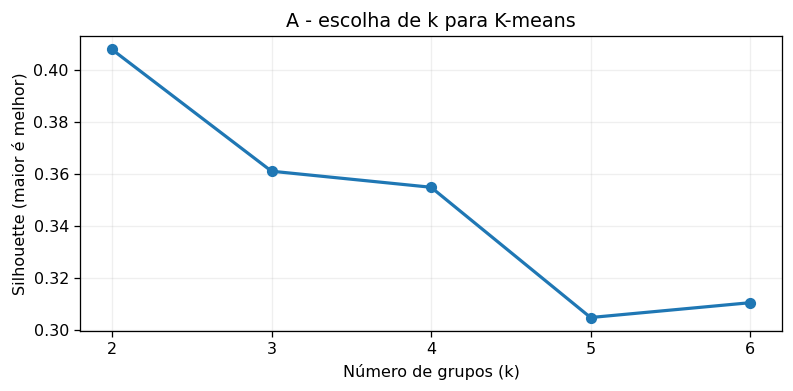

In [4]:
avaliacao_a = []
for k in range(2, 7):
    labels = KMeans(n_clusters=k, n_init=50, random_state=42).fit_predict(X_a)
    avaliacao_a.append({'k': k, 'silhouette': silhouette_score(X_a, labels)})
avaliacao_a = pd.DataFrame(avaliacao_a)
display(avaliacao_a.round(3))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(avaliacao_a.k, avaliacao_a.silhouette, marker='o', linewidth=2)
ax.set(xticks=avaliacao_a.k, xlabel='Número de grupos (k)', ylabel='Silhouette (maior é melhor)', title='A - escolha de k para K-means')
plt.tight_layout(); plt.show()

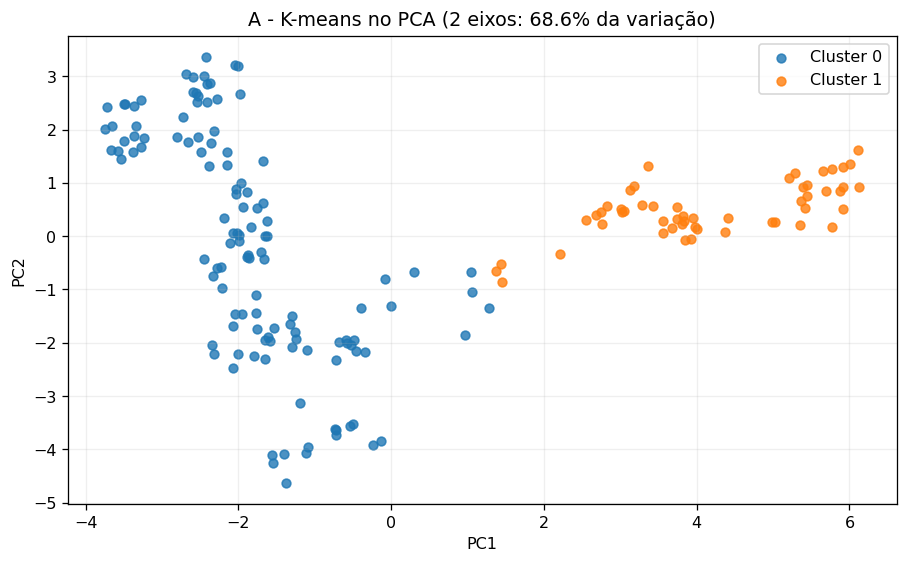

Tamanho dos grupos: {0: 121, 1: 53}
Silhouette de A: 0.408
ARI com Regime_Inflacao: 0.015


In [5]:
k_a = 2
modelo_a = KMeans(n_clusters=k_a, n_init=50, random_state=42)
clusters_a = pd.Series(modelo_a.fit_predict(X_a), index=X_a.index, name='Cluster')
pca_a = PCA(n_components=2).fit(X_a)
pontos_a = pca_a.transform(X_a)
fig, ax = plt.subplots(figsize=(8, 5))
for c in sorted(clusters_a.unique()):
    mask = clusters_a.to_numpy() == c
    ax.scatter(pontos_a[mask, 0], pontos_a[mask, 1], s=30, alpha=.8, label=f'Cluster {c}')
ax.set(xlabel='PC1', ylabel='PC2', title=f'A - K-means no PCA (2 eixos: {pca_a.explained_variance_ratio_.sum():.1%} da variação)')
ax.legend(); plt.tight_layout(); plt.show()
print('Tamanho dos grupos:', clusters_a.value_counts().sort_index().to_dict())
print(f'Silhouette de A: {silhouette_score(X_a, clusters_a):.3f}')
print(f'ARI com Regime_Inflacao: {adjusted_rand_score(referencia.loc[X_a.index, "Regime_Inflacao"], clusters_a):.3f}')

Meses por cluster e regime (referência externa):


Regime_Inflacao,Alta / Acima da Meta,Deflação,Meta / Estável
Cluster,,,
0,54,16,51
1,16,11,26


IPCA médio por cluster (% ao mês):


Cluster
0    0.479
1    0.325
Name: IPCA, dtype: float64

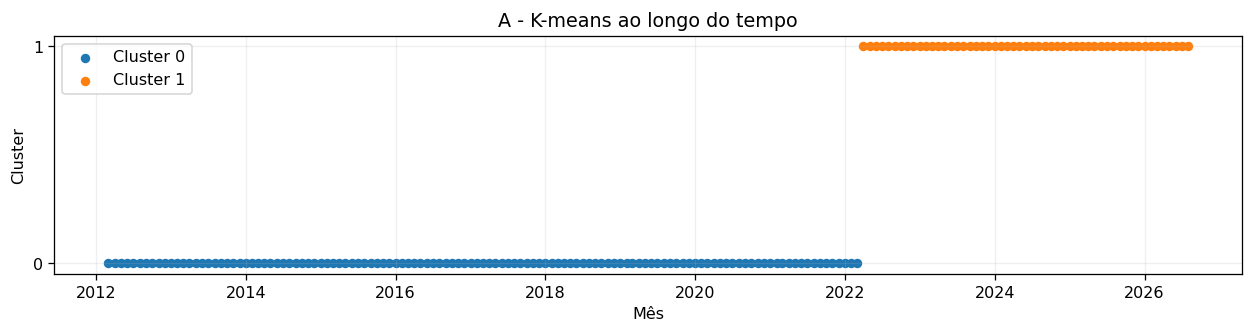

In [6]:
print('Meses por cluster e regime (referência externa):')
display(pd.crosstab(clusters_a, referencia.loc[clusters_a.index, 'Regime_Inflacao']))
print('IPCA médio por cluster (% ao mês):')
display(referencia.loc[clusters_a.index, 'IPCA'].groupby(clusters_a).mean().round(3))
fig, ax = plt.subplots(figsize=(11, 3))
for c in sorted(clusters_a.unique()):
    mask = clusters_a == c
    ax.scatter(clusters_a.index[mask], clusters_a[mask], s=24, label=f'Cluster {c}')
ax.set(yticks=sorted(clusters_a.unique()), xlabel='Mês', ylabel='Cluster', title='A - K-means ao longo do tempo')
ax.legend(); plt.tight_layout(); plt.show()

## B. Componentes do IPCA com hierárquico Ward

Usamos somente componentes setoriais do IPCA. O filtro de correlação evita colunas muito semelhantes. A padronização precede a distância euclidiana e o método de Ward.

In [7]:
mantidos_b, removidos_b = [], []
for coluna in componentes_ipca:
    if any(abs(df[coluna].corr(df[m])) >= .85 for m in mantidos_b):
        removidos_b.append(coluna)
    else:
        mantidos_b.append(coluna)
base_b = df.set_index('Date')[mantidos_b].copy()
X_b = pd.DataFrame(StandardScaler().fit_transform(base_b), index=base_b.index, columns=base_b.columns)
print(f'B: {len(base_b)} meses e {base_b.shape[1]} componentes')
print('Componentes:', mantidos_b)
print('Removidos pelo filtro:', removidos_b)

B: 174 meses e 6 componentes
Componentes: ['IPCA_Transportes', 'IPCA Alimentação_bebidas', 'IPCA_Saúde_cuidados_pessoais', 'IPCA_Vestuário', 'IPCA_Educação', 'IPCA_Despesas_Pessoais']
Removidos pelo filtro: []


,k,silhouette
0,2,0.179
1,3,0.223
2,4,0.235
3,5,0.221
4,6,0.189


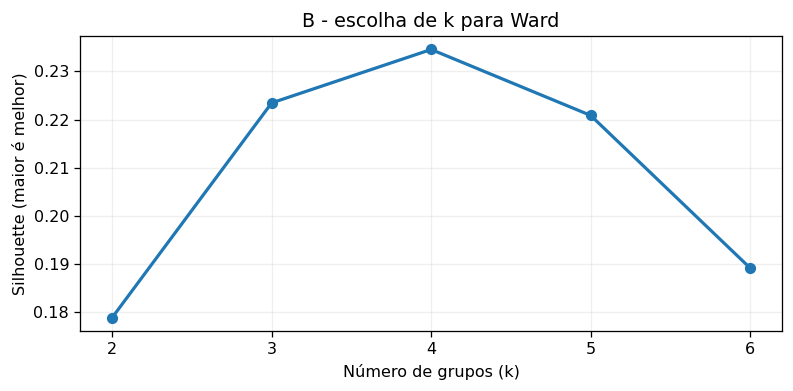

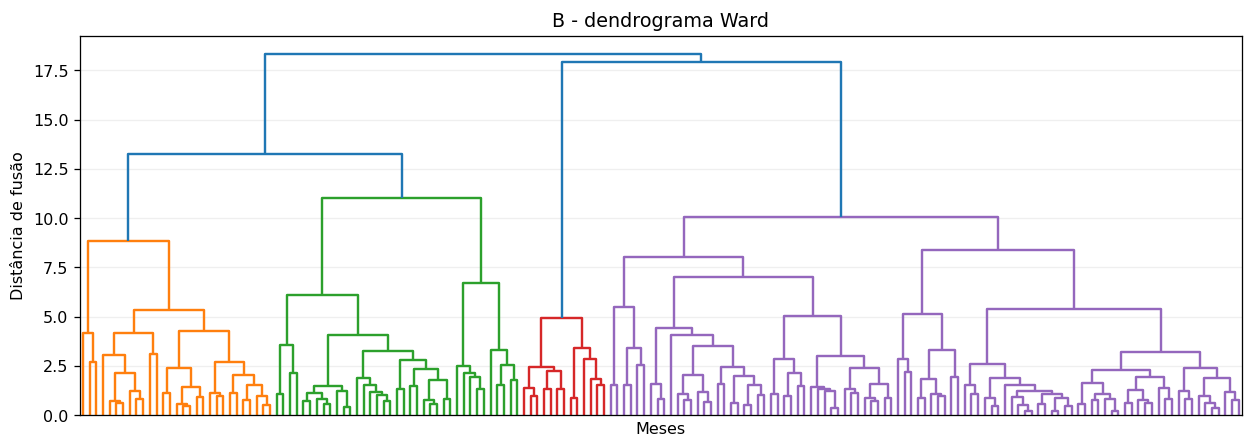

In [8]:
avaliacao_b = []
for k in range(2, 7):
    labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_b)
    avaliacao_b.append({'k': k, 'silhouette': silhouette_score(X_b, labels)})
avaliacao_b = pd.DataFrame(avaliacao_b)
display(avaliacao_b.round(3))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(avaliacao_b.k, avaliacao_b.silhouette, marker='o', linewidth=2)
ax.set(xticks=avaliacao_b.k, xlabel='Número de grupos (k)', ylabel='Silhouette (maior é melhor)', title='B - escolha de k para Ward')
plt.tight_layout(); plt.show()
fig, ax = plt.subplots(figsize=(11, 4))
dendrogram(linkage(X_b, method='ward', metric='euclidean'), no_labels=True, ax=ax)
ax.set(xlabel='Meses', ylabel='Distância de fusão', title='B - dendrograma Ward')
plt.tight_layout(); plt.show()

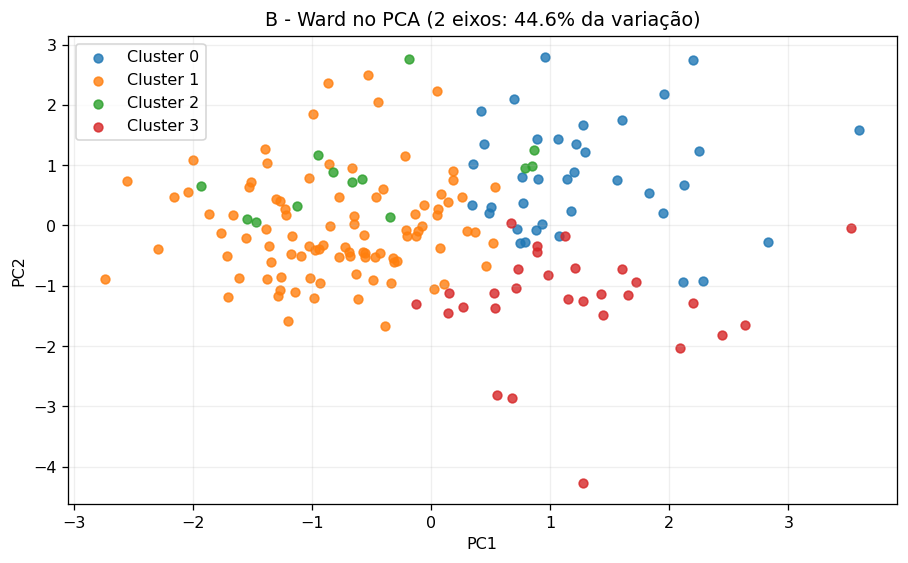

Tamanho dos grupos: {0: 37, 1: 95, 2: 13, 3: 29}
Silhouette de B: 0.235
ARI com Regime_Inflacao: 0.071


In [9]:
k_b = 4
clusters_b = pd.Series(AgglomerativeClustering(n_clusters=k_b, linkage='ward').fit_predict(X_b), index=X_b.index, name='Cluster')
pca_b = PCA(n_components=2).fit(X_b)
pontos_b = pca_b.transform(X_b)
fig, ax = plt.subplots(figsize=(8, 5))
for c in sorted(clusters_b.unique()):
    mask = clusters_b.to_numpy() == c
    ax.scatter(pontos_b[mask, 0], pontos_b[mask, 1], s=30, alpha=.8, label=f'Cluster {c}')
ax.set(xlabel='PC1', ylabel='PC2', title=f'B - Ward no PCA (2 eixos: {pca_b.explained_variance_ratio_.sum():.1%} da variação)')
ax.legend(); plt.tight_layout(); plt.show()
print('Tamanho dos grupos:', clusters_b.value_counts().sort_index().to_dict())
print(f'Silhouette de B: {silhouette_score(X_b, clusters_b):.3f}')
print(f'ARI com Regime_Inflacao: {adjusted_rand_score(referencia.loc[X_b.index, "Regime_Inflacao"], clusters_b):.3f}')

Resumo dos grupos B:


,Meses,IPCA médio (%)
Cluster,,
0,37,0.932
1,95,0.223
2,13,0.358
3,29,0.513


Média mensal dos componentes por grupo (%):


,IPCA_Transportes,IPCA Alimentação_bebidas,IPCA_Saúde_cuidados_pessoais,IPCA_Vestuário,IPCA_Educação,IPCA_Despesas_Pessoais
Cluster,,,,,,
0,1.070,1.287,0.483,0.722,0.160,0.836
1,0.308,0.217,0.337,0.161,0.146,0.368
2,0.530,0.565,0.665,-0.109,5.084,0.419
3,-0.288,0.821,1.142,0.806,0.155,0.508


Meses por cluster e regime (referência externa):


Regime_Inflacao,Alta / Acima da Meta,Deflação,Meta / Estável
Cluster,,,
0,30,0,7
1,21,24,50
2,5,2,6
3,14,1,14


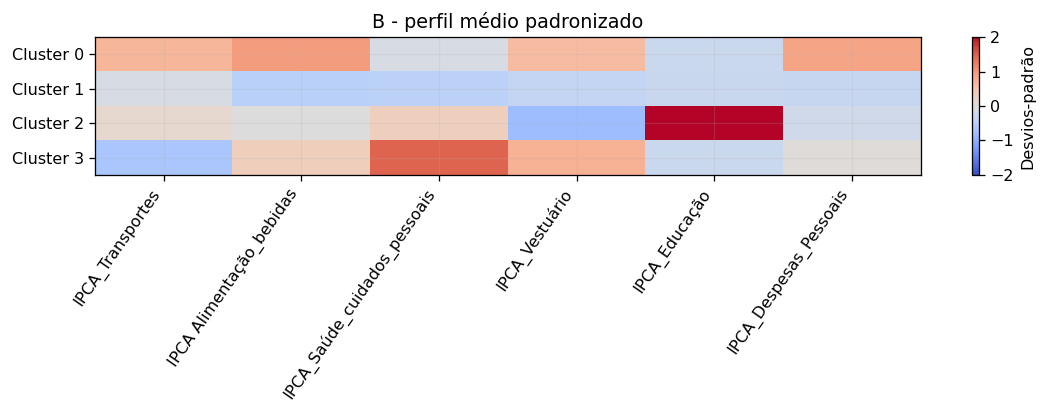

In [10]:
perfil_b = base_b.groupby(clusters_b).mean()
resumo_b = pd.DataFrame({
    'Meses': clusters_b.value_counts().sort_index(),
    'IPCA médio (%)': referencia.loc[clusters_b.index, 'IPCA'].groupby(clusters_b).mean(),
})
print('Resumo dos grupos B:')
display(resumo_b.round(3))
print('Média mensal dos componentes por grupo (%):')
display(perfil_b.round(3))
print('Meses por cluster e regime (referência externa):')
display(pd.crosstab(clusters_b, referencia.loc[clusters_b.index, 'Regime_Inflacao']))
fig, ax = plt.subplots(figsize=(10, 3.7))
perfil_z = X_b.groupby(clusters_b).mean()
im = ax.imshow(perfil_z, cmap='coolwarm', vmin=-2, vmax=2, aspect='auto')
ax.set(xticks=range(len(perfil_z.columns)), yticks=range(len(perfil_z)), yticklabels=[f'Cluster {i}' for i in perfil_z.index], title='B - perfil médio padronizado')
ax.set_xticklabels(perfil_z.columns, rotation=55, ha='right')
fig.colorbar(im, ax=ax, label='Desvios-padrão')
plt.tight_layout(); plt.show()

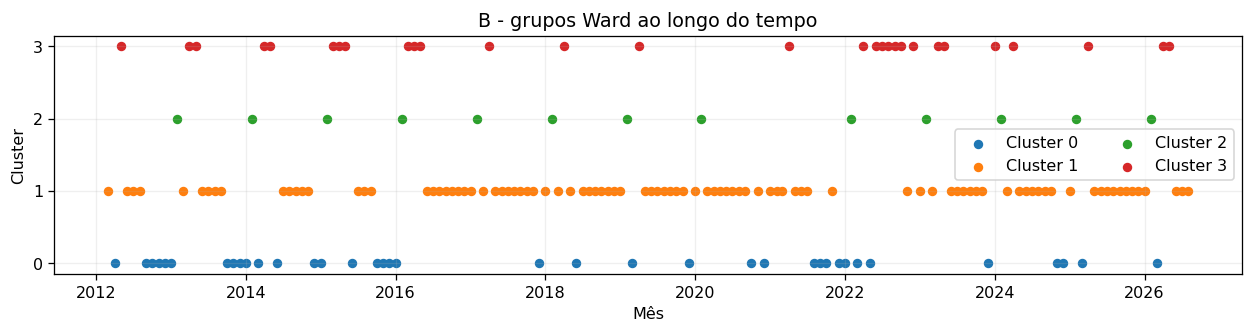

Meses de fevereiro por grupo:


col_0,Outros meses,Fevereiro
Cluster,,
0,37,0
1,94,1
2,0,13
3,29,0


In [11]:
fig, ax = plt.subplots(figsize=(11, 3))
for c in sorted(clusters_b.unique()):
    mask = clusters_b == c
    ax.scatter(clusters_b.index[mask], clusters_b[mask], s=24, label=f'Cluster {c}')
ax.set(yticks=sorted(clusters_b.unique()), xlabel='Mês', ylabel='Cluster', title='B - grupos Ward ao longo do tempo')
ax.legend(ncol=2); plt.tight_layout(); plt.show()
print('Meses de fevereiro por grupo:')
display(pd.crosstab(clusters_b, clusters_b.index.month == 2).rename(columns={False: 'Outros meses', True: 'Fevereiro'}))

## Como interpretar

- **A:** o K-means resume os meses a partir das variáveis macroeconômicas; a linha do tempo mostra se a divisão acompanha períodos históricos.
- **B:** Ward agrupa meses pela semelhança dos componentes do IPCA. As médias e o heatmap ajudam a descrever os perfis.
- **Limite:** `Regime_Inflacao` é uma referência posterior à clusterização, derivada do IPCA geral. Os componentes de B integram esse índice; a comparação não é validação independente nem previsão.